In [1]:
import xarray as xr
import glob

In [2]:
# Get all monthly files
files_e = sorted(glob.glob("total-energy-flux-eastward_monthly_2022*_v1.0.nc"))
files_n = sorted(glob.glob("total-energy-flux-northward_monthly_2022*_v1.0.nc"))

# Open and combine along time
ds_e = xr.open_mfdataset(files_e, combine="by_coords")
ds_n = xr.open_mfdataset(files_n, combine="by_coords")


# # Compute time mean
# lhfln_mean = ds_le["lhfln"].mean(dim="time")
# tefln_mean = ds_te["tefln"].mean(dim="time")

In [3]:
print(ds_e)
print(ds_n)

<xarray.Dataset> Size: 50MB
Dimensions:    (time: 12, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 96B 2022-01-15 2022-02-15 ... 2022-12-15
  * latitude   (latitude) float32 3kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    tefle      (time, latitude, longitude) float32 50MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    version:      v1.0
<xarray.Dataset> Size: 50MB
Dimensions:    (time: 12, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 96B 2022-01-15 2022-02-15 ... 2022-12-15
  * latitude   (latitude) float32 3kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    tefln      (time, latitude, longitude) float32 50MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    Conven

In [4]:
from windspharm.xarray import VectorWind

def windspharm_time_loop(uh_int, vh_int):
    """
    Compute divergent component for each time step
    """
    Flambda_div_list = []
    Fphi_div_list = []
    
    for t in range(len(uh_int.time)):
        # Extract single time step
        u_t = uh_int.isel(time=t)
        v_t = vh_int.isel(time=t)
        
        # VectorWind requires (lat, lon) with no NaNs
        u_filled = u_t.fillna(0.0)
        v_filled = v_t.fillna(0.0)
        
        # Compute divergent component
        vw = VectorWind(u_filled, v_filled)
        u_div, v_div = vw.irrotationalcomponent()  # Changed here!
        
        Flambda_div_list.append(u_div)
        Fphi_div_list.append(v_div)
    
    # Concatenate back along time dimension
    Flambda_div = xr.concat(Flambda_div_list, dim='time')
    Fphi_div = xr.concat(Fphi_div_list, dim='time')
    
    # Assign time coordinates
    Flambda_div = Flambda_div.assign_coords(time=uh_int.time)
    Fphi_div = Fphi_div.assign_coords(time=vh_int.time)
    
    return Flambda_div, Fphi_div



In [5]:
# Use it
uh_int = ds_e['tefle']  # Already integrated
vh_int = ds_n['tefln']  # Already integrated



In [6]:
uh_int

<xarray.DataArray 'tefle' (time: 12, latitude: 721, longitude: 1440)> Size: 50MB
dask.array<concatenate, shape=(12, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 96B 2022-01-15 2022-02-15 ... 2022-12-15
  * latitude   (latitude) float32 3kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    long_name:  Vertical integral of eastward total energy flux
    units:      W m**-1

In [7]:
vh_int

<xarray.DataArray 'tefln' (time: 12, latitude: 721, longitude: 1440)> Size: 50MB
dask.array<concatenate, shape=(12, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 96B 2022-01-15 2022-02-15 ... 2022-12-15
  * latitude   (latitude) float32 3kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    long_name:  Vertical integral of northward total energy flux
    units:      W m**-1

In [8]:
Flambda_div, Fphi_div = windspharm_time_loop(uh_int, vh_int)

In [9]:
Fphi_div_mean = Fphi_div.mean(dim='time')

In [10]:
Fphi_div_mean

<xarray.DataArray 'v_chi' (latitude: 721, longitude: 1440)> Size: 4MB
array([[ 4617250.5,  4707819. ,  4798294.5, ...,  4345029. ,  4435856. ,
         4526599.5],
       [ 6565952.5,  6653786. ,  6741511.5, ...,  6301822. ,  6389969.5,
         6478012.5],
       [ 8511102. ,  8593855. ,  8676478. , ...,  8262092. ,  8345220.5,
         8428225. ],
       ...,
       [29609602. , 29451670. , 29293192. , ..., 30080110. , 29923830. ,
        29766986. ],
       [32337190. , 32176010. , 32014208. , ..., 32816966. , 32657674. ,
        32497746. ],
       [34322912. , 34164092. , 34004620. , ..., 34795440. , 34638588. ,
        34481084. ]], shape=(721, 1440), dtype=float32)
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

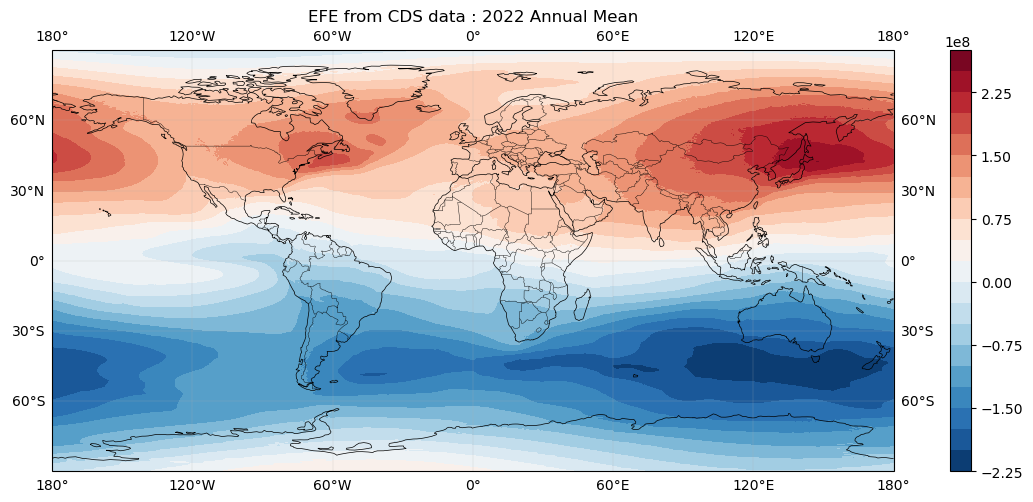

In [12]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
v = Fphi_div_mean

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.longitude, v.latitude, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title(f'EFE from CDS data : 2022 Annual Mean')
plt.tight_layout()
plt.savefig('CDS_MSE_map.png', dpi=150)
plt.show()



In [13]:
Fphi_div = xr.DataArray(Fphi_div, dims=vh_int.dims, coords=vh_int.coords)

# Compute zonal mean
Fphi_div_zonal = Fphi_div.mean(dim=['time', 'longitude'])

# Find zero crossing
for i in range(len(Fphi_div_zonal.latitude) - 1):
    if Fphi_div_zonal.values[i] * Fphi_div_zonal.values[i+1] < 0:
        lat1 = Fphi_div_zonal.latitude.values[i]
        lat2 = Fphi_div_zonal.latitude.values[i+1]
        val1 = Fphi_div_zonal.values[i]
        val2 = Fphi_div_zonal.values[i+1]
        efe_lat = lat1 - val1 * (lat2 - lat1) / (val2 - val1)
        print(f"EFE at: {efe_lat:.2f}°N")

EFE at: -2.90°N


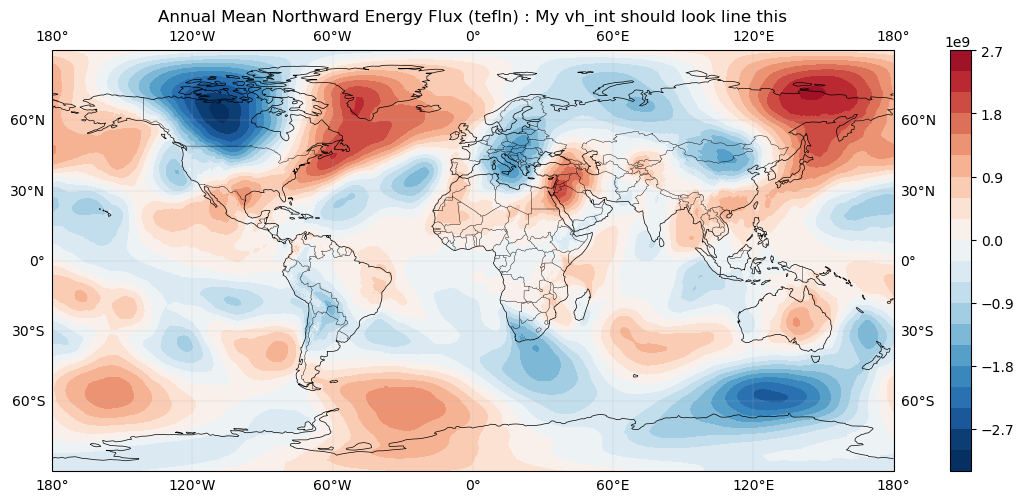

In [14]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
v = ds_n['tefln'].mean(dim='time')

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Set colorbar limits: -3e9 to 3e9
vmin = -3e9
vmax = 3e9

im = ax.contourf(v.longitude, v.latitude, v,
                 levels=20, cmap='RdBu_r', 
                 vmin=vmin, vmax=vmax,
                 transform=ccrs.PlateCarree())

# im = ax.contourf(v.longitude, v.latitude, v,
#                  levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title(f'Annual Mean Northward Energy Flux (tefln) : My vh_int should look like this')
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



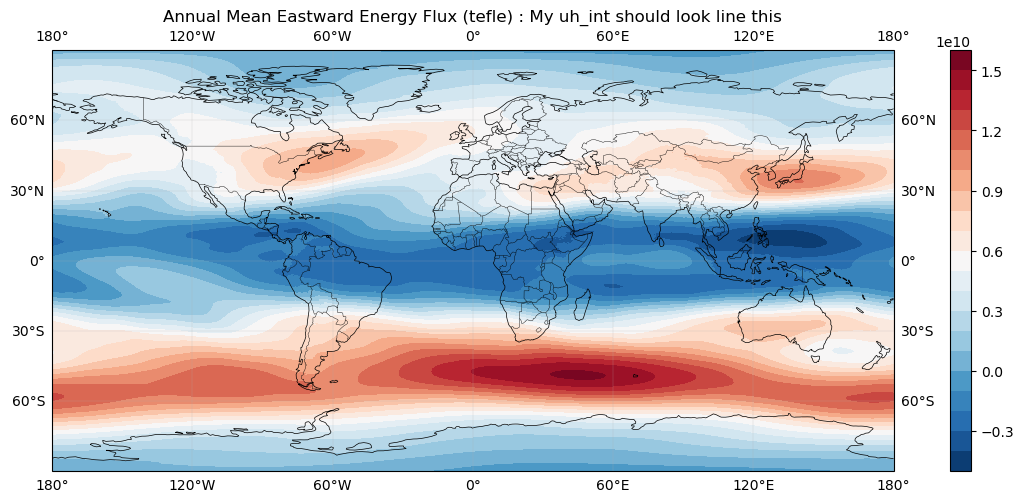

In [15]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
v = ds_e['tefle'].mean(dim='time')

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.longitude, v.latitude, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title(f'Annual Mean Eastward Energy Flux (tefle) : My uh_int should look like this')
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



In [16]:
print("=" * 50)
print("DIAGNOSTICS:")
print("=" * 50)
# print("h range:", h.min().values, "to", h.max().values)
# print("u range:", u_filled.min().values, "to", u_filled.max().values)
# print("v range:", v_filled.min().values, "to", v_filled.max().values)
# print()
# print("uh range:", uh.min().values, "to", uh.max().values)
# print("vh range:", vh.min().values, "to", vh.max().values)
# print()
print("uh_int range:", uh_int.min().values, "to", uh_int.max().values)
print("vh_int range:", vh_int.min().values, "to", vh_int.max().values)
print()
print("uh_int typical value:", uh_int.mean().values)
print("vh_int typical value:", vh_int.mean().values)

DIAGNOSTICS:
uh_int range: -9653047000.0 to 22041280000.0
vh_int range: -8735817000.0 to 8392466400.0

uh_int typical value: 3880134400.0
vh_int typical value: -3909182.8


In [17]:
print("ERA5 tefle attributes:")
print(ds_e['tefle'].attrs)
print("\nERA5 tefln attributes:")
print(ds_n['tefln'].attrs)

ERA5 tefle attributes:
{'long_name': 'Vertical integral of eastward total energy flux', 'units': 'W m**-1'}

ERA5 tefln attributes:
{'long_name': 'Vertical integral of northward total energy flux', 'units': 'W m**-1'}
